In [11]:
import pandas as pd
import glob

In [12]:
# Tüm raw dosyalarını bul
raw_files = glob.glob("../data/raw/firms_*.csv")
print(f"Bulunan dosya sayısı: {len(raw_files)}")

Bulunan dosya sayısı: 15


In [13]:
dfs = []
for file in raw_files:
    df = pd.read_csv(file)
    if len(df) > 0:
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)
print(f"Toplam satır sayısı: {len(all_data)}")

Toplam satır sayısı: 1516


In [14]:
duplicate_count = all_data.duplicated(subset=['latitude', 'longitude', 'acq_date', 'acq_time']).sum()
print(f"Duplicate satır sayısı: {duplicate_count}")

Duplicate satır sayısı: 1056


In [6]:
duplicated_rows = all_data[all_data.duplicated(subset=['latitude', 'longitude', 'acq_date', 'acq_time'], keep=False)]
duplicated_rows.sort_values(['latitude', 'longitude']).head(10)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
76,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
225,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
493,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
642,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
791,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
1059,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
77,35.52826,44.34468,330.36,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,295.34,4.72,N
226,35.52826,44.34468,330.36,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,295.34,4.72,N
494,35.52826,44.34468,330.36,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,295.34,4.72,N
643,35.52826,44.34468,330.36,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,295.34,4.72,N


In [15]:
clean_data = all_data.drop_duplicates(subset=['latitude', 'longitude', 'acq_date', 'acq_time'], keep='first')
print(f"Temizlik öncesi: {len(all_data)}")
print(f"Temizlik sonrası: {len(clean_data)}")

Temizlik öncesi: 1516
Temizlik sonrası: 460


In [16]:
clean_data.to_csv("../data/processed/clean_hotspots.csv", index=False)
print(f"Kaydedildi: {len(clean_data)} satır")

Kaydedildi: 460 satır


In [17]:
#Genel yapı kontrolü
clean_data.info()
clean_data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 0 to 1332
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    460 non-null    float64
 1   longitude   460 non-null    float64
 2   bright_ti4  460 non-null    float64
 3   scan        460 non-null    float64
 4   track       460 non-null    float64
 5   acq_date    460 non-null    object 
 6   acq_time    460 non-null    int64  
 7   satellite   460 non-null    object 
 8   instrument  460 non-null    object 
 9   confidence  460 non-null    object 
 10  version     460 non-null    object 
 11  bright_ti5  460 non-null    float64
 12  frp         460 non-null    float64
 13  daynight    460 non-null    object 
dtypes: float64(7), int64(1), object(6)
memory usage: 53.9+ KB


,latitude,longitude,bright_ti4,scan,track,acq_time,bright_ti5,frp
count,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000
mean,37.780005,37.915647,337.394326,0.487043,0.557652,686.836957,304.359848,8.057565
std,1.751819,5.130639,20.081873,0.121580,0.129525,491.440758,9.706340,9.143409
min,35.526560,25.638550,295.670000,0.320000,0.360000,9.000000,284.290000,0.330000
25%,36.455343,34.573470,318.512500,0.390000,0.440000,11.000000,295.552500,2.410000
50%,37.081635,38.720815,342.655000,0.450000,0.560000,943.000000,305.960000,5.850000
75%,39.024408,42.995585,350.207500,0.570000,0.670000,1115.000000,311.530000,9.915000
max,42.154980,44.428180,367.000000,0.790000,0.780000,1134.000000,325.740000,83.510000


In [18]:
#Coğrafi sınır kontrolü
print(f"Enlem aralığı: {clean_data['latitude'].min()} - {clean_data['latitude'].max()}")
print(f"Boylam aralığı: {clean_data['longitude'].min()} - {clean_data['longitude'].max()}")

Enlem aralığı: 35.52656 - 42.15498
Boylam aralığı: 25.63855 - 44.42818


In [19]:
#Confidence ve daynight dağılımı
print(clean_data['confidence'].value_counts())
print(clean_data['daynight'].value_counts())

confidence
n    399
h     61
Name: count, dtype: int64
daynight
D    302
N    158
Name: count, dtype: int64



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.10.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-macosx_10_9_universal2.whl.metadata (118 kB)
  Using cached pillow-12.3.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-macosx_10_9_universal2.whl (2.9 MB)
Using cached pillow-12.3.0-cp310-cp310-macosx_11_0_arm64.whl (4

<Axes: >

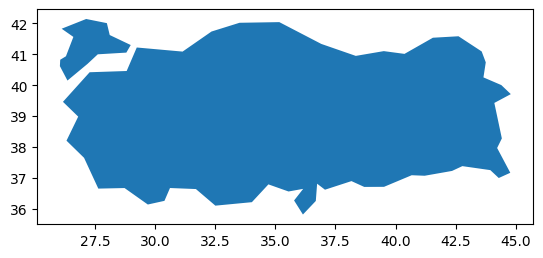

In [23]:
%pip install geopandas
%pip install matplotlib
import geopandas as gpd

turkey_boundary = gpd.read_file("https://raw.githubusercontent.com/johan/world.geo.json/master/countries/TUR.geo.json")
turkey_boundary.plot()